#Pontfelhők feldolgozása

Ez az összeálltás a gita Műszaki térinformatika egyesület 2026. évi konferenciájának workshopjához készült. A tananyag és a használt képek a BME Általános és Felsőgeodézia Tanszék Geo4All laborjának GitHub oldaláról letölthetők.

## Bevezetés

### Pontfelhőkben tárolt adatok

A pontfelhőkben a pozíció mellett további adatok is tárolásra kerülhetnek.

### Pontfelhők tárolási formátumai

A térinformatikához hasonlóan sokféle adatformátum használatos a pontfelhő állományok tárolására. Ezek között találhatók nyílt formátumok és zárt formátumok.

A nyílt formátumok esetén az állomány belső struktúrájának leírása bárki számára elérhető és ez alapján készíthet olyan programot, mely a formátumot olvasni és írni képes. Néhány, Magyarországon elterjedt nyílt polfelhő formátum: LAS, LAZ, e57, XYZ, PLY, PCD

A zárt formátumok egyes kereskedelmi szotverekhez kötődnek, azokat csak a megfelelő szoftvercsomag megvásárlása esetén tudjuk kezelni. Ilyen formátumok például az RCS és a RCP.

Az egyes tárolási formátumok közötti választásnál mérlegelni kell a metaadatok (intenzitás, szín, osztályozás) megőrzését, a fájlméretet/tömöríthetőséget illetve a szoftver kompatibilitást.

### Pontfelhőlhők előállítási technológiái

A pontfelhők előállításának két fő technológiája létezik a lézeres távmérés (LiDAR) és a fotogrammetria (SfM). A LiDAR technológia több részterületre bontható TLS, ALS, SLAM, stb.

### Nyílt forráskódú programok pontfelhők kezelésére

*   CloudCompare - grafikus felhasználói felület és programozási
*   PDAL - programkönyvtár és parancssori eszközök
*   PCL - programkönyvtár
*   Open3D - programkönyvtár Python programokhoz
*   Potree - internetes megjelenítés



### Szükséges programkönyvtárak és adatok teltöltése

A példák során a Python programnyelvet és az Open3D könyvtárat használjuk.

In [1]:
!pip uninstall -q -y ipywidgets
!pip install -q open3d
!pip install -q cloth-simulation-filter
!pip install -q plotly

A feladatok során néhány mintaállományt használunk

In [2]:
!wget -q https://github.com/OSGeoLabBp/tutorials/raw/refs/heads/master/hungarian/pointcloud/data/GITA_Test1_Off-ground_points.las
!wget -q https://github.com/OSGeoLabBp/tutorials/raw/refs/heads/master/hungarian/pointcloud/data/minta1.ply

## Nyers pontfelhők előkészítése

A nyers pontfelhők jellemzően zajjal terheltek. Olyan pontok jelenhetnek benne,melyek a valóságban nincsenek illetve a pontok sűrűsége túl nagy az adott feladatunkhoz. Mindkét esetben a pontfelhőben lévő pontok közül bizonyosakat eltávolítunk. A döntési kritériumban van különbség, ami alapján egy pontot megőrzünk vagy kihagyunk.

### Zajszűrési módszerek

A zajszűrésnél használt fontosabb módszerek:

* statisztikai módszerek (Statistical Outlier Removal, Radius Outlier Removal)
* geometriai módszerek (pl. RANSAC)
* PCA alapú módszerek
* mélytanulás alapú módszerek

In [27]:
import numpy as np
import open3d as o3d
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import CSF
from osgeo import gdal

In [17]:
def pc_show(pc, width=800, height=600, voxel_size=0.1):
    """ Pontfelhő megjelenítése csökkentett felbontással"""
    pc1 = pc.voxel_down_sample(voxel_size=voxel_size)
    pts = np.asarray(pc1.points)
    cols = np.asarray(pc1.colors)

    # megjelenítés
    fig = go.Figure(data=[
        go.Scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
            mode='markers', marker=dict(size=1, color=cols,))
    ])
    # Customize layout
    fig.update_layout(width=1000, height=700,
        scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False)),
        margin=dict(l=0, r=0, b=0, t=0)
    )

    fig.show()

In [18]:
pc = o3d.io.read_point_cloud('minta1.ply')
pc_show(pc)

Output hidden; open in https://colab.research.google.com to view.

### Statistical Outlier Removal (SOR)

A zaj pontok megtalálása statisztikai alapon. Számítsuk ki minden egyes pontra a **k** legközelebbi szomszéd átlagos távolságát.

$d_i = \frac {1} {k} \sum_{j=1}^k || p_i - p_{ij} ||$

Számítsuk ki ezen távolságok átlagát és szórását

$\mu = \frac 1 {n} \sum_{i=1}^n d_i$

$\sigma = \sqrt \frac {\sum_{i=1}^n (d_i - \mu)^2} {n-1}$

Vizsgáljuk meg minden pontra, hogy a k legközelebbi szomszéd átlagos távolsága nagyobb-e mint a globális átlag szórással megnövelt értéke.

$d_i > \mu + \alpha \cdot \sigma$

$\alpha$ általában 1-3 közé eső konstans.

In [ ]:
NB_NEIGHBORS = 25   # szomszédos pontok száma 10 - 50 között
STD_RATIO = 1       # alfa 1-3 között
sor_pc, _ = pc.remove_statistical_outlier(nb_neighbors=NB_NEIGHBORS, std_ratio=STD_RATIO)
o3d.io.write_point_cloud('minta1_sor.ply', sor_pc)
print(f"{len(pc.points)-len(sor_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(sor_pc.points)/len(pc.points)*100:.1f}%.")

130018 pont eltávolítva a 1273830 közül, 10.2%.


### Radius Outlier Removal

A kevés közeli szomszéddal rendelkező pontokat tekintjük zajnak. Minden egyes pontra keressük meg egy R sugarú környezetébe eső pontokat, ha ezek száma egy korlátnál kevesebb, akkor eltávolítjuk a pontot.

In [ ]:
RADIUS = 0.3
LIMIT = 10
ror_pc, _ = pc.remove_radius_outlier(nb_points=LIMIT, radius=RADIUS)
o3d.io.write_point_cloud('minta1_ror.ply', ror_pc)
print(f"{len(pc.points)-len(ror_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(ror_pc.points)/len(pc.points)*100:.1f}%.")

3376 pont eltávolítva a 1273830 közül, 0.3%.


### Pontfelhő ritkitása

A pontfelhő ritkítására léteznek nagyon egyszerű módszerek. Például minden n. pont eltávolítása vagy véletlenszerűen válaszott pontok eltávolítása. Ezeknél célszerűbb megoldás a szomszédos pontok közötti minimális távolsággal vagy pontsűrűség alapján történő szűrés.

#### Voxel alapú ritkítás

Osszuk fel a pontfelhő pontjait a minimális távolság méretű kis kockákra (voxelekre). Minden voxelen belül csak egy pontot őrizzünk meg, ha esnek pontok a voxelbe.

In [ ]:
VOXEL_SIZE = 0.05  # minimális távolság a pontok között
vox_pc = pc.voxel_down_sample(voxel_size=VOXEL_SIZE)
o3d.io.write_point_cloud('minta1_vox.ply', vox_pc)
print(f"{len(pc.points)-len(vox_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(vox_pc.points)/len(pc.points)*100:.1f}%.")

597679 pont eltávolítva a 1273830 közül, 46.9%.


#### Nyolcas fa alapú ritkítás

A nyolcas fa egy 3D térbeli indexelési módszer is, melyet mot a pontfelhő ritkítása során használjuk fel. A nyolcas fa kialakítása során a pontok befoglaló kockájából indulunk ki. A kocka éleinek felezésével nyolc kis kockára bonjuk, addig folytatjuk ezt a felbontást, amíg egy adott felbontási mélységet elérünk vagy az egyes a kisebb kockákba eső pontok száma egy korlátnál kisebb.

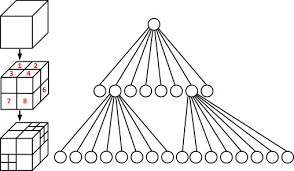

In [ ]:
# nyolcas fa
MAX_DEPTH = 10   # fa maximális mélysége a terjedelem és felbontás alapján
octree = o3d.geometry.Octree(max_depth=MAX_DEPTH)   # nyolcas fa étrehozása
octree.convert_from_point_cloud(pc)
down_points = []    # lista a ritkított pontok tárolásához
# segédfüggvény a nyolcas fa bejárásához
def traverse(node, node_info):
    if isinstance(node, o3d.geometry.OctreeLeafNode):   # a fa levele?
        if len(node.indices) > 0:
            pts = np.asarray(pc.points)[node.indices]
            centroid = pts.mean(axis=0)
            down_points.append(centroid)
    return False  # continue traversal
octree.traverse(traverse)   # nyolcas fa bejárása
# pontfelhő a szűrt pontokból
oct_pc = o3d.geometry.PointCloud()
oct_pc.points = o3d.utility.Vector3dVector(np.array(down_points))

# mentés fájlba
o3d.io.write_point_cloud("minta1_oct.ply", oct_pc)
print(f"{len(pc.points)-len(oct_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(oct_pc.points)/len(pc.points)*100:.1f}%.")

[5.50903414e+05 1.82409105e+05 2.81604279e+02] [5.50947448e+05 1.82444303e+05 3.12428375e+02] 10
804256
469574 pont eltávolítva a 1273830 közül, 36.9%.


## Pontfelhők szegmentálása

A pontfelhők előállítása során jellemzően egy strukturálatlan adatállomány áll elő. A feldolgozás során a pontfelhő szegmentálása egy fontos feladat. A talaj, növényzet, épület, stb. pontok elkülönítésére sokféle módszert dolgoztak ki.

### Talajpontok elkülönítése

A talajpontok elkülönítésére a Cloth Simulation Filter (CSF) egy elterjedt módszer. Az eljárás alapgondolata, hogy tükrözzük a pontfelhőt az XY síkra. Helyezzünk egy lepedőt a pontokra, mely a gravitáció következtében rásimul a pontokra, de az anyag "merevsége" miatt áthidalja a "réseket". A lepedő közelében található pontokat talajpontoknak minősítjük.

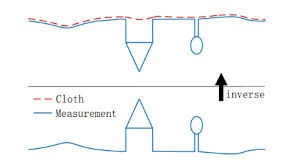

In [23]:
pc_xyz = np.asarray(pc.points)
csf = CSF.CSF()
csf.params.cloth_resolution = 0.5   # rácsméret a simulációhoz
csf.params.rigidness = 3    # 1 hegyvidék, 2 complex táj, 3 sima terület magas épületekkel
#csf.params.time_step = 0.65
csf.params.class_threshold = 0.5   # távolság limit a lepedőtől
csf.params.iterations = 500
csf.params.bSloopSmooth = True    # utólagos simítás

csf.setPointCloud(pc_xyz)
ground = CSF.VecInt()
non_ground = CSF.VecInt()
csf.do_filtering(ground, non_ground, exportCloth=False)
pc_ground = pc.select_by_index(ground)
pc_non_ground = pc.select_by_index(non_ground)
o3d.io.write_point_cloud("minta1_talaj.ply", pc_ground)
o3d.io.write_point_cloud("minta1_nemtalaj.ply", pc_ground)
print(f"{len(pc.points)} pont közül {len(pc_ground.points)} talajpont, {len(pc_non_ground.points)} nem talajpont.")

1273830 pont közül 836533 talajpont, 437297 nem talajpont.


Talajpontok

In [24]:
pc_show(pc_ground)

Output hidden; open in https://colab.research.google.com to view.

Nem talajpontok

In [25]:
pc_show(pc_non_ground)

Output hidden; open in https://colab.research.google.com to view.

A talajpontok felhasználásával létrehozhatunk egy négyzetrács alapú digitális domborzatmodelt.